## Сегментация изображений клеток

Вам предстоит обучить модель сегментировать изображения с дрожжевыми клетками и микроструктурами, по пути поэкспериментировав с разными архитектурами и функциями ошибки.

### Задание 1 (2 балл). Метрики сегментации
Перед экспериментами нужно определиться с метриками. Выберите 3-5 метрик, по которым вы будете оценивать качество модели. В этом задании объясните свой выбор и найдите нужные метрики в `torchmetrics` (а если их нет - реализуйте самостоятельно)

In [1]:
from torchmetrics.segmentation import MeanIoU
from torchmetrics import Accuracy, Precision

MeanIoU (среднее по классам пересечение по объединению) — стандартная метрика для семантической сегментации, учитывает как правильную классификацию, так и форму сегментов.

Precision — важна для оценки, насколько модель точно определяет классы, без ложных срабатываний.

Обычная Accuracy — общая доля правильно классифицированных пикселей.

### Задание 2 (4 балла). Обучение модели
Возьмите модель и датасеты из практики по сегментации и запустите обучение.

Указания:
- Каждую эпоху сохраняйте значения ошибки и выбранные в задании 1 метрики как для обучающего датасета (`train`), так и для валидационного (`val`).
- Каждую эпоху сохраняйте примеры работы модели на 8 случайных изображениях из валидационного датасета (одной картинкой, как в практике).
- После окончания обучения выведите графики значений ваших метрик и примеры предсказаний (достаточно 4-5 изображений: для первой эпохи, 2-3 в середине обучения и для последней эпохи).
- Можете использовать `lightning` (вместо `lightning.pytorch.loggers.TensorBoardLogger` можно использовать `lightning.pytorch.loggers.CSVLogger`, а сохранение изображений можете реализовать как `lightning.pytorch.Callback`), а можете всё написать вручную.

Все, что ниже и до реализации самого задания, - из ноутбука по сегментации.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch import Tensor
from torch.utils.data import Dataset
from torchvision import transforms
import os
import json

In [3]:
# ! wget https://tudatalib.ulb.tu-darmstadt.de/bitstream/handle/tudatalib/3799/yeast_cell_in_microstructures_dataset.zip
# ! unzip yeast_cell_in_microstructures_dataset.zip -d yeast_cell_in_microstructures_dataset

In [4]:
class YeastSemanticSegmDataset(Dataset):
    def __init__(self, subset_dir: Path) -> None:
        super().__init__()
        self.subset_dir = subset_dir
        self.items = list((self.subset_dir / "inputs").glob("*.pt"))

    def __getitem__(self, index: int) -> tuple[Tensor, Tensor]:
        image_path = self.items[index]
        image = torch.load(image_path, weights_only=True).unsqueeze(0)  # (W, H) -> (1, W, H)
        # 0 класс - фон, поэтому прибавляем 1 к меткам классов
        labels = torch.load(self.subset_dir / "classes" / image_path.name, weights_only=True) + 1
        masks = torch.load(self.subset_dir / "instances" / image_path.name, weights_only=True)

        # формируем маску: тензор размера W x H, где для каждого пиксела указан класс
        masks = ((masks * labels.view(-1, 1, 1)).sum(dim=0)).long()
        return image, masks

    def __len__(self) -> int:
        return len(self.items)

In [5]:
from pathlib import Path

import lightning as L
from lightning.pytorch.utilities.types import EVAL_DATALOADERS, TRAIN_DATALOADERS
from torch.utils.data import DataLoader

class DataModule(L.LightningDataModule):
    def __init__(
        self,
        datadir: Path,
        batch_size: int,
        train_subdir: str = "train",
        val_subdir: str = "val",
        test_subdir: str = "test",
    ) -> None:
        super().__init__()
        self.batch_size = batch_size
        datadir = Path(datadir)
        self.train_dir = datadir / train_subdir
        self.val_dir = datadir / val_subdir
        self.test_dir = datadir / test_subdir

    def setup(self, stage: str) -> None:
        if stage in ("fit", "validate"):
            self.val_dataset = YeastSemanticSegmDataset(self.val_dir)
        if stage == "fit":
            self.train_dataset = YeastSemanticSegmDataset(self.train_dir)
        elif stage == "test":
            self.test_dataset = YeastSemanticSegmDataset(self.test_dir)

    def train_dataloader(self) -> TRAIN_DATALOADERS:
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
        )

    def val_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
        )

    def test_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
        )

In [6]:
torch.manual_seed(42)
datamodule = DataModule(
    datadir=Path("yeast_cell_in_microstructures_dataset"),
    batch_size=8,
)
datamodule.setup("fit")
images, masks = next(iter(datamodule.train_dataloader()))
print(images.shape)
print(masks.shape)

torch.Size([8, 1, 256, 256])
torch.Size([8, 256, 256])


In [7]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(
        self, in_channels: int, out_channels: int, mid_channels: int | None = None
    ) -> None:
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.double_conv(x)

In [8]:
x_in = torch.randn(4, 3, 64, 64)
x_out = DoubleConv(3, 16).forward(x_in)
print(f"{x_in.shape} -> {x_out.shape}")

torch.Size([4, 3, 64, 64]) -> torch.Size([4, 16, 64, 64])


In [9]:
class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2), DoubleConv(in_channels, out_channels)
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.maxpool_conv(x)

In [10]:
x_in = torch.randn(4, 3, 64, 64)
x_out = Down(3, 16).forward(x_in)
print(f"{x_in.shape} -> {x_out.shape}")

torch.Size([4, 3, 64, 64]) -> torch.Size([4, 16, 32, 32])


In [11]:
def create_downscaler(channel_sizes: list[int], bilinear: bool = False) -> nn.ModuleList:
    """
    Создаём список модулей на основе размеров каналов.
    если используется билинейная интерполяция вместо обратной свёртки,
    то размер последнего (самого большого) канала делаем вдвое меньше

    Args:
        channel_sizes (list[int]): список размеров каналов, напр. [16, 32, 64]
        bilinear (bool, optional): если True, в модели используется билинейная интерполяция
            для выравнивания размеров активаций.
    """
    modules = []
    for i in range(len(channel_sizes) - 1):
        in_channels = channel_sizes[i]
        out_channels = channel_sizes[i + 1]
        is_last_module = i == len(channel_sizes) - 2
        # Определяем факторы масштабирования для каждого слоя
        dfactor = 2 if bilinear and is_last_module else 1
        modules.append(Down(in_channels, out_channels // dfactor))

    return nn.ModuleList(modules)

In [12]:
x_in = torch.randn(4, 16, 32, 32)
downscaler = create_downscaler(channel_sizes=[16, 32, 64, 128], bilinear=False)
x_out = x_in
for conv in downscaler:
    x_out = conv(x_out)
print(f"{x_in.shape} -> {x_out.shape}")

torch.Size([4, 16, 32, 32]) -> torch.Size([4, 128, 4, 4])


In [13]:
from torch import nn

x = torch.tensor([[0, 1], [2, 3]], dtype=float).view(1, 2, 2)
kernel = torch.tensor([[4, 1], [2, 3]], dtype=float).view(1, 1, 2, 2)
deconv = nn.ConvTranspose2d(1, 1, kernel_size=2, bias=False)
deconv.weight.data = kernel
deconv(x)

tensor([[[ 0.,  4.,  1.],
         [ 8., 16.,  6.],
         [ 4., 12.,  9.]]], dtype=torch.float64, grad_fn=<SqueezeBackward1>)

In [14]:
class Up(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, bilinear: bool = True) -> None:
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x_prev: Tensor, x_skip: Tensor) -> Tensor:
        x_prev = self.up(x_prev)
        x = torch.cat([x_skip, x_prev], dim=1)
        return self.conv(x)

In [15]:
x_in = torch.randn(4, 64, 4, 4)
x_skip = torch.randn(4, 32, 8, 8)
x_out = Up(64, 32, bilinear=False).forward(x_in, x_skip)
print(f"{x_in.shape} -> {x_out.shape}")

torch.Size([4, 64, 4, 4]) -> torch.Size([4, 32, 8, 8])


In [16]:
def create_upscaler(channel_sizes: list[int], bilinear: bool = False) -> nn.ModuleList:
    """
    Создаём список модулей на основе размеров каналов.
    Если используется билинейная интерполяция вместо обратной свёртки,
    то размер первого (самого большого) канала делаем вдвое меньше

    Args:
        channel_sizes (list[int]): список размеров каналов, напр. [64, 32, 16]
        bilinear (bool, optional): если True, в модели используется билинейная интерполяция
            для выравнивания размеров активаций.
    """
    modules = []
    for i in range(len(channel_sizes) - 1):
        in_channels = channel_sizes[i]
        out_channels = channel_sizes[i + 1]
        is_last_module = i == len(channel_sizes) - 2
        # Определяем факторы масштабирования для каждого слоя
        dfactor = 2 if bilinear and not is_last_module else 1
        modules.append(Up(in_channels, out_channels // dfactor, bilinear=bilinear))

    return nn.ModuleList(modules)

In [17]:
x_in = torch.randn(4, 16, 32, 32)
bilinear = False
downscaler = create_downscaler(channel_sizes=[16, 32, 64, 128], bilinear=bilinear)
upscaler = create_upscaler(channel_sizes=[128, 64, 32, 16], bilinear=bilinear)

# Понижаем разрешение
x_mid = x_in
xs = []
for conv in downscaler:
    xs.append(x_mid)
    x_mid = conv(x_mid)

# Повышаем обратно
xs.reverse()
x_out = x_mid
for conv, x_prev in zip(upscaler, xs):
    x_out = conv(x_out, x_prev)


print(f"{x_in.shape} -> {x_mid.shape} -> {x_out.shape}")

torch.Size([4, 16, 32, 32]) -> torch.Size([4, 128, 4, 4]) -> torch.Size([4, 16, 32, 32])


In [18]:
class UNet(nn.Module):
    def __init__(
        self,
        n_channels: int,
        n_classes: int,
        channel_sizes: list[int],
        bilinear: bool = False,
    ):
        super().__init__()
        self.in_conv = DoubleConv(in_channels=n_channels, out_channels=channel_sizes[0])
        self.downscaler = create_downscaler(channel_sizes, bilinear)
        self.upscaler = create_upscaler(channel_sizes[::-1], bilinear)
        self.head = nn.Conv2d(channel_sizes[0], n_classes, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        # делаем входную свёртку
        x = self.in_conv(x)

        # downscaling
        xs = []
        for conv in self.downscaler:
            xs.append(x)
            x = conv(x)

        # разворачиваем промежуточные активации и делаем upscaling
        xs.reverse()
        for conv, act in zip(self.upscaler, xs):
            x = conv(x, act)

        # финальная свёртка для получения логитов пикселей
        logits = self.head(x)
        return logits

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [20]:
torch.manual_seed(42)
model = UNet(n_channels=1, n_classes=3, channel_sizes=[16, 32, 64, 128], bilinear=True)
model = model.to(device)
sum([p.numel() for p in model.parameters()])

268515

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

### Реализация задания

In [22]:
def calculate_metrics(predictions, targets, device):
    pred_classes = predictions.argmax(dim=1)
    
    # Создаем объекты метрик на GPU
    iou_metric = MeanIoU(num_classes=3).to(device)
    precision_metric = Precision(task="multiclass", num_classes=3, average='macro').to(device)
    acc_metric = Accuracy(task="multiclass", num_classes=3, average='micro').to(device)
    
    # Вычисляем метрики
    iou = iou_metric(pred_classes, targets)
    precision = precision_metric(pred_classes, targets)
    acc = acc_metric(pred_classes, targets)
    
    return {
        'iou': iou,
        'precision': precision, 
        'accuracy': acc
    }

In [23]:
def save_metrics_to_file(train_losses, val_losses, train_metrics, val_metrics, filename="training_metrics.json"):
    """Сохраняет все метрики в JSON файл"""
    metrics_data = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics
    }
    
    with open(filename, 'w') as f:
        json.dump(metrics_data, f, indent=2)

def load_metrics_from_file(filename="training_metrics.json"):
    """Загружает метрики из JSON файла"""
    with open(filename, 'r') as f:
        metrics_data = json.load(f)
    
    return (metrics_data['train_losses'], metrics_data['val_losses'],
            metrics_data['train_metrics'], metrics_data['val_metrics'])

In [24]:
def plot_metrics_from_file(filename="training_metrics.json", experiment_name="Experiment"):
    """Строит графики из сохраненных метрик"""
    train_losses, val_losses, train_metrics, val_metrics = load_metrics_from_file(filename)
    
    plt.figure(figsize=(20, 5))
    
    # 1. Loss
    plt.subplot(1, 4, 1)
    plt.plot(train_losses, label='Train', marker='o')
    plt.plot(val_losses, label='Val', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{experiment_name} - Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2. IoU
    plt.subplot(1, 4, 2)
    train_ious = [m['iou'] for m in train_metrics]
    val_ious = [m['iou'] for m in val_metrics]
    plt.plot(train_ious, label='Train', marker='o')
    plt.plot(val_ious, label='Val', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.title(f'{experiment_name} - IoU')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 3. Precision
    plt.subplot(1, 4, 3)
    train_precisions = [m['precision'] for m in train_metrics]
    val_precisions = [m['precision'] for m in val_metrics]
    plt.plot(train_precisions, label='Train', marker='o')
    plt.plot(val_precisions, label='Val', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.title(f'{experiment_name} - Precision')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 4. Accuracy
    plt.subplot(1, 4, 4)
    train_accuracies = [m['accuracy'] for m in train_metrics]
    val_accuracies = [m['accuracy'] for m in val_metrics]
    plt.plot(train_accuracies, label='Train', marker='o')
    plt.plot(val_accuracies, label='Val', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{experiment_name} - Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{experiment_name}_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

In [25]:
val_dataset = datamodule.val_dataset
fixed_indices = torch.randperm(len(val_dataset))[:8].tolist()
print(f"Fixed indices for tracking: {fixed_indices}")

Fixed indices for tracking: [17, 42, 19, 1, 39, 11, 41, 37]


In [26]:
def save_8_val_images(model, device, epoch, indices=fixed_indices, save_dir="val_images"):
    os.makedirs(save_dir, exist_ok=True)
    
    # Собираем изображения по фиксированным индексам
    images = []
    masks = []
    for idx in indices:
        img, mask = val_dataset[idx]
        images.append(img)
        masks.append(mask)
    
    # Преобразуем в тензоры и переносим на устройство
    images = torch.stack(images).to(device)
    masks = torch.stack(masks).to(device)
    
    # Получаем предсказания модели
    with torch.no_grad():
        predictions = model(images)
    
    # Визуализация как в практике
    original_images_grid = torchvision.utils.make_grid(images, nrow=4, normalize=True)
    masks_grid = torchvision.utils.make_grid(
        torch.nn.functional.one_hot(predictions.argmax(dim=1), 3).permute(0, 3, 1, 2)[:, 1:]
        > 0,
        nrow=4,
    )

    predictions_grid = torchvision.utils.draw_segmentation_masks(
        original_images_grid,
        masks=masks_grid,
        alpha=0.4,
        colors=["red", "green"],
    )

    plt.figure(figsize=(12, 5))
    plt.axis("off")
    plt.title(f"Epoch {epoch}")
    plt.imshow(transforms.ToPILImage()(predictions_grid))
    plt.savefig(f"{save_dir}/epoch_{epoch:03d}.png", dpi=150, bbox_inches='tight')
    plt.close()

In [27]:
def run_experiment(model, loss_fn, optimizer, datamodule, num_epochs=15, experiment_name="experiment"):
    """
    Универсальная функция для запуска экспериментов с разными loss функциями
    """
    # Создаем папки для эксперимента
    save_dir = f"val_images_{experiment_name}"
    metrics_file = f"training_metrics_{experiment_name}.json"
    
    train_losses = []
    val_losses = []
    train_metrics = []
    val_metrics = []

    # Фиксируем индексы для валидационных изображений
    val_dataset = datamodule.val_dataset
    fixed_indices = torch.randperm(len(val_dataset))[:8].tolist()
    print(f"Fixed indices for {experiment_name}: {fixed_indices}")

    for epoch in range(num_epochs):
        # Train phase
        model.train()
        total_train_loss = 0
        train_epoch_metrics = {'iou': 0, 'precision': 0, 'accuracy': 0}
        num_batches = 0
        
        for images, masks in datamodule.train_dataloader():
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            predictions = model(images)
            loss = loss_fn(predictions, masks)
            loss.backward()
            optimizer.step()
            
            batch_metrics = calculate_metrics(predictions, masks, device)
            
            total_train_loss += loss.item()
            for key in train_epoch_metrics:
                train_epoch_metrics[key] += batch_metrics[key].item()
            num_batches += 1
            
        avg_train_loss = total_train_loss / num_batches
        for key in train_epoch_metrics:
            train_epoch_metrics[key] /= num_batches
        
        train_losses.append(avg_train_loss)
        train_metrics.append(train_epoch_metrics)
        
        # Validation phase
        model.eval()
        save_8_val_images(model, device, epoch, indices=fixed_indices, save_dir=save_dir)
        total_val_loss = 0
        val_epoch_metrics = {'iou': 0, 'precision': 0, 'accuracy': 0}
        num_val_batches = 0
        
        with torch.no_grad():
            for images, masks in datamodule.val_dataloader():
                images = images.to(device)
                masks = masks.to(device)
                
                predictions = model(images)
                loss = loss_fn(predictions, masks)
                
                batch_metrics = calculate_metrics(predictions, masks, device)
                
                total_val_loss += loss.item()
                for key in val_epoch_metrics:
                    val_epoch_metrics[key] += batch_metrics[key].item()
                num_val_batches += 1
                
        avg_val_loss = total_val_loss / num_val_batches
        for key in val_epoch_metrics:
            val_epoch_metrics[key] /= num_val_batches
            
        val_losses.append(avg_val_loss)
        val_metrics.append(val_epoch_metrics)
        
        # Сохраняем метрики
        save_metrics_to_file(train_losses, val_losses, train_metrics, val_metrics, metrics_file)
        
        print(f"{experiment_name} - Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train - Loss: {avg_train_loss:.4f}, IoU: {train_epoch_metrics['iou']:.4f}, "
              f"Precision: {train_epoch_metrics['precision']:.4f}, Acc: {train_epoch_metrics['accuracy']:.4f}")
        print(f"  Val   - Loss: {avg_val_loss:.4f}, IoU: {val_epoch_metrics['iou']:.4f}, "
              f"Precision: {val_epoch_metrics['precision']:.4f}, Acc: {val_epoch_metrics['accuracy']:.4f}")
        print()
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'model': model
    }

In [28]:
# Эксперимент 1: CrossEntropy (baseline)
torch.manual_seed(42)
model_ce = UNet(n_channels=1, n_classes=3, channel_sizes=[16, 32, 64, 128], bilinear=True).to(device)
optimizer_ce = torch.optim.Adam(model_ce.parameters(), lr=0.01)

print("=== CrossEntropy Experiment ===")
results_ce = run_experiment(
    model=model_ce,
    loss_fn=F.cross_entropy,
    optimizer=optimizer_ce,
    datamodule=datamodule,
    num_epochs=15,
    experiment_name="cross_entropy"
)

=== CrossEntropy Experiment ===
Fixed indices for cross_entropy: [17, 42, 19, 1, 39, 11, 41, 37]
cross_entropy - Epoch 1/15:
  Train - Loss: 0.4280, IoU: 0.3951, Precision: 0.6415, Acc: 0.8554
  Val   - Loss: 1.2462, IoU: 0.2445, Precision: 0.5113, Acc: 0.7152

cross_entropy - Epoch 2/15:
  Train - Loss: 0.2187, IoU: 0.5986, Precision: 0.8237, Acc: 0.9155
  Val   - Loss: 0.1960, IoU: 0.6184, Precision: 0.8658, Acc: 0.9244

cross_entropy - Epoch 3/15:
  Train - Loss: 0.1582, IoU: 0.6990, Precision: 0.8794, Acc: 0.9374
  Val   - Loss: 0.1820, IoU: 0.6480, Precision: 0.8415, Acc: 0.9253

cross_entropy - Epoch 4/15:
  Train - Loss: 0.1263, IoU: 0.7454, Precision: 0.9041, Acc: 0.9493
  Val   - Loss: 0.1918, IoU: 0.6353, Precision: 0.8503, Acc: 0.9226

cross_entropy - Epoch 5/15:
  Train - Loss: 0.1030, IoU: 0.7838, Precision: 0.9252, Acc: 0.9583
  Val   - Loss: 0.1009, IoU: 0.7842, Precision: 0.9132, Acc: 0.9595

cross_entropy - Epoch 6/15:
  Train - Loss: 0.1004, IoU: 0.7869, Precision: 0.

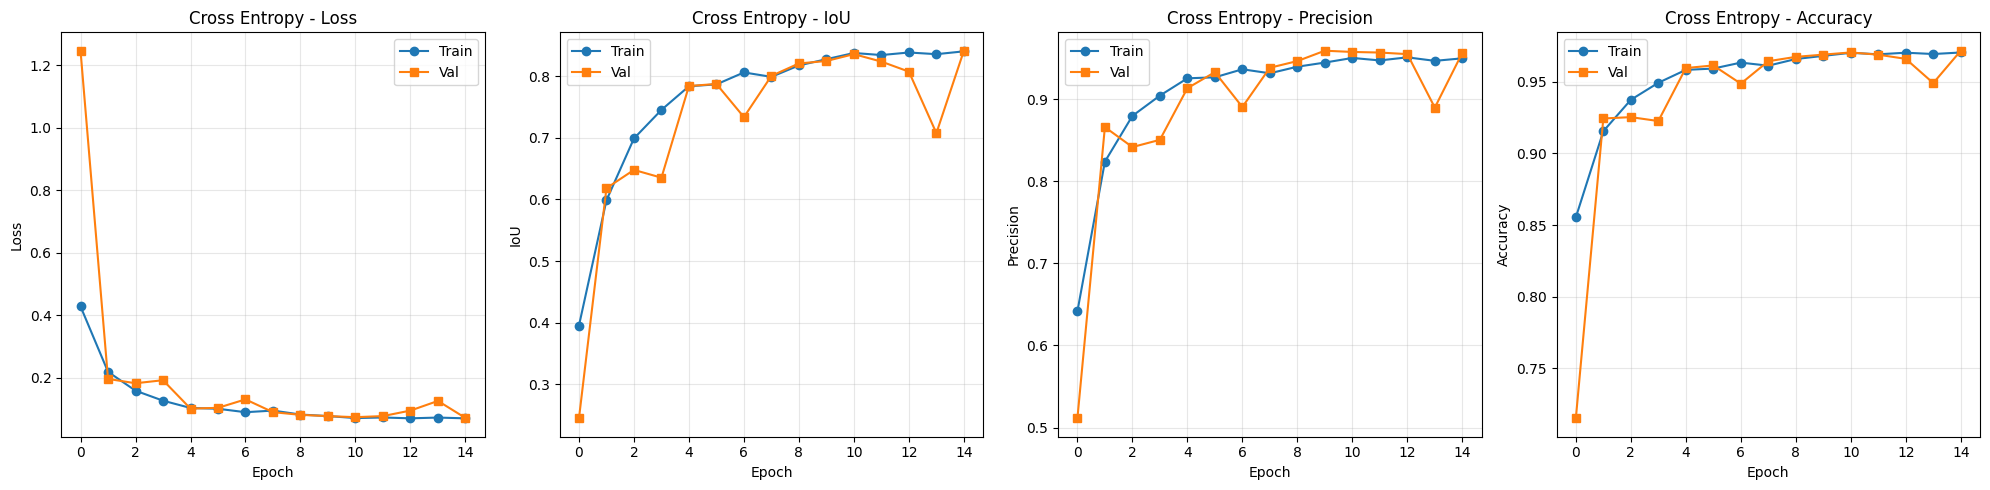

In [29]:
# Строим графики
plot_metrics_from_file("training_metrics_cross_entropy.json", "Cross Entropy")

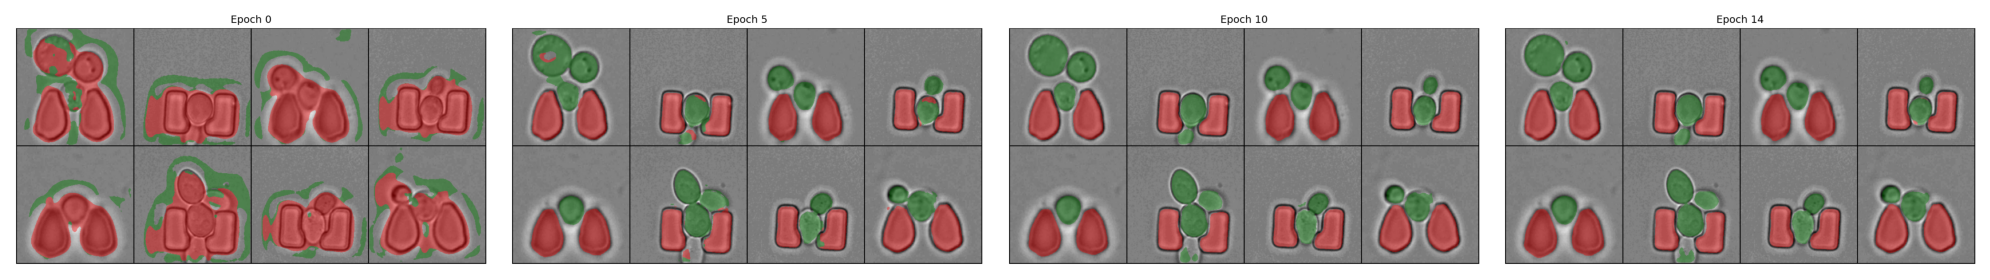

In [30]:
def show_val_images_comparison(epochs_to_show=[0, 5, 10, 14], save_dir="val_images"):
    """Показывает предсказания для выбранных эпох"""
    
    fig, axes = plt.subplots(1, len(epochs_to_show), figsize=(20, 5))
    
    for i, epoch in enumerate(epochs_to_show):
        img_path = f"{save_dir}/epoch_{epoch:03d}.png"
        if os.path.exists(img_path):
            img = plt.imread(img_path)
            axes[i].imshow(img)
            axes[i].axis('off')
        else:
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('epochs_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Вызов после обучения
show_val_images_comparison()

### Задание 3 (3 балла). Выбор другой функции ошибки

Полезная ссылка:
https://www.jeremyjordan.me/semantic-segmentation/#loss

Повторите эксперимент из задания 2, но попробуйте модифицировать функцию ошибки:
- (2 балла) учитывайте пиксели на границе объектов с большим весом, как предлагается в статье [U-Net](https://arxiv.org/abs/1505.04597)
- (1 балл) используйте soft Dice loss

Опишите свои наблюдения, что изменилось? Обратите внимание на скорость обучения, визуальные артефакты предсказаний, динамику метрик.


Реализовано только soft Dice loss, поэтому не вывожу картинки, так как не было заметного прогресса с точки зрения детекции границ объектов

In [31]:
class SoftDiceLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, y_pred, y_true):
        num_classes = y_pred.shape[1]
        y_true_one_hot = F.one_hot(y_true, num_classes).permute(0, 3, 1, 2).float()
        
        y_pred_softmax = F.softmax(y_pred, dim=1)
        
        dice_scores = []
        for class_idx in range(num_classes):
            pred_channel = y_pred_softmax[:, class_idx, :, :]
            true_channel = y_true_one_hot[:, class_idx, :, :]
            
            intersection = torch.sum(pred_channel * true_channel, dim=(1, 2))
            union = torch.sum(pred_channel, dim=(1, 2)) + torch.sum(true_channel, dim=(1, 2))
            
            dice_score = (2. * intersection + self.epsilon) / (union + self.epsilon)
            dice_scores.append(dice_score)
        
        dice_scores = torch.stack(dice_scores, dim=1)
        dice_loss = 1 - dice_scores.mean()
        
        return dice_loss
    
dice_loss_fn = SoftDiceLoss().to(device)

In [32]:
# Эксперимент 2: Dice Loss
torch.manual_seed(42)
model_dice = UNet(n_channels=1, n_classes=3, channel_sizes=[16, 32, 64, 128], bilinear=True).to(device)
optimizer_dice = torch.optim.Adam(model_dice.parameters(), lr=0.01)

print("=== Dice Loss Experiment ===")
results_dice = run_experiment(
    model=model_dice,
    loss_fn=dice_loss_fn,
    optimizer=optimizer_dice,
    datamodule=datamodule,
    num_epochs=15,
    experiment_name="dice_loss"
)

=== Dice Loss Experiment ===
Fixed indices for dice_loss: [17, 42, 19, 1, 39, 11, 41, 37]
dice_loss - Epoch 1/15:
  Train - Loss: 0.3959, IoU: 0.4349, Precision: 0.6849, Acc: 0.8468
  Val   - Loss: 0.5535, IoU: 0.2452, Precision: 0.5666, Acc: 0.6757

dice_loss - Epoch 2/15:
  Train - Loss: 0.1945, IoU: 0.6614, Precision: 0.8425, Acc: 0.9233
  Val   - Loss: 0.1693, IoU: 0.6780, Precision: 0.8890, Acc: 0.9347

dice_loss - Epoch 3/15:
  Train - Loss: 0.1607, IoU: 0.7204, Precision: 0.8825, Acc: 0.9413
  Val   - Loss: 0.1539, IoU: 0.6614, Precision: 0.8461, Acc: 0.9263

dice_loss - Epoch 4/15:
  Train - Loss: 0.1670, IoU: 0.7060, Precision: 0.8749, Acc: 0.9387
  Val   - Loss: 0.1348, IoU: 0.7094, Precision: 0.8774, Acc: 0.9423

dice_loss - Epoch 5/15:
  Train - Loss: 0.1379, IoU: 0.7718, Precision: 0.9104, Acc: 0.9543
  Val   - Loss: 0.1093, IoU: 0.7685, Precision: 0.9308, Acc: 0.9597

dice_loss - Epoch 6/15:
  Train - Loss: 0.1313, IoU: 0.7874, Precision: 0.9219, Acc: 0.9586
  Val   - Los

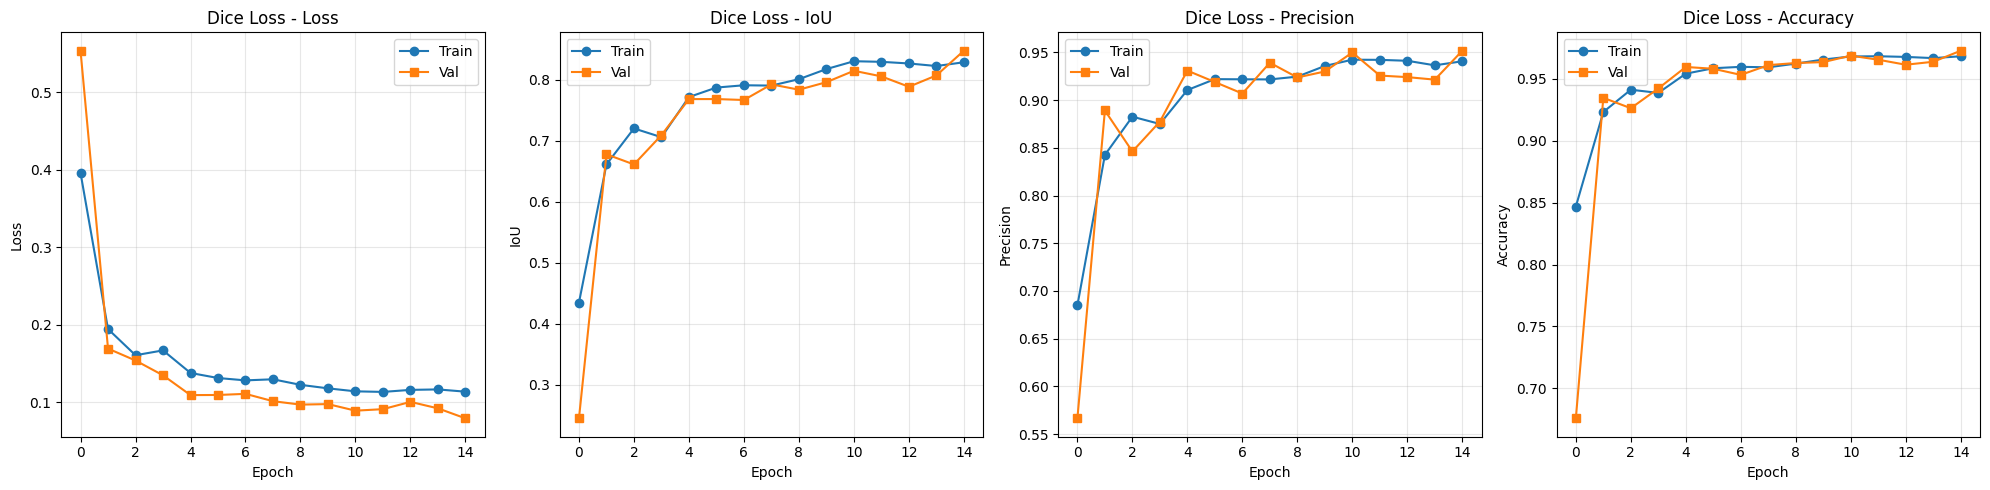

In [33]:
plot_metrics_from_file("training_metrics_dice_loss.json", "Dice Loss")

Анализ:
Если смотреть на динамику Loss, то различия очень незначительны. Как будто у кросс-энтропии получилось вначале чуть быстрее обучиться (на первых эпохах), далее скорость снижения ошибки почти одинаковая. Особенно заметно на train, что вначале у CE есть преимущество, но вот валидационный Loss почти одинаково меняется

А вот по метрикам очень хорошо видно преимущество dice. Кросс-энтропию довольно сильно колбасит, на 3, 6 и 13 эпохах мы видим резкие скачки. А вот dice обучается довольно плавно, хотя и нельзя сказать, что монотонно. На метрике Precision видно несколько раз снижения, но это только в этом эксперименте случилось, обычно было примерно как в Accuracy: быстро достигалось почти максимальное значение и потом понемного увеличивалось или колебалось вокруг него.

### Задание 4 (3 балла). Модификация архитектуры (не делал)


Ваша задача - извлечь максимальную точность из модели, в которой будет не более 50k параметров. Для этого внесите правки в архитектуру модели.

В частности, попробуйте заменить в блоке `Down` комбинацию conv+maxpool на dilated conv с увеличенным stride (`nn.Conv2d(..., dilation=2, stride=2)`). В остальном - полная свобода творчества, можете перерабатывать архитектуру как угодно.

Ожидается, что просадка в точности по всем метрикам не будет превышать 10%; в частности, accuracy 90% вполне достижима.

Как обычно, запустите эксперимент (или несколько) с выводом всех графиков и картинок.